<a href="https://colab.research.google.com/github/saskiaalifah/SaskiaAlifah_2411531002_BigData26/blob/main/Praktikum1/BD_A_P01_2411531002_Saskia_Alifah.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BD_A_P01_2411531002_SaskiaAlifah

**Praktikum 1 — Pengenalan Big Data & Lingkungan Kerja, serta Pengolahan Dataset Big Data Menggunakan Python**




## J-1. Verifikasi Lingkungan Kerja

**Tujuan:** mengetahui persis mesin apa yang dipakai, karena semua kesimpulan performa nanti hanya berlaku untuk spesifikasi ini.

In [2]:
import sys, platform, multiprocessing

print("Python  :", sys.version.split()[0])
print("OS      :", platform.platform())
print("CPU core:", multiprocessing.cpu_count())

for nama in ["pandas", "numpy", "pyarrow", "matplotlib"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")

Python  : 3.13.15
OS      : Linux-6.6.122+-x86_64-with-glibc2.39
CPU core: 2
pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
matplotlib : 3.10.0


In [3]:
!free -h         # kapasitas dan sisa RAM
!df -h /content 2>/dev/null || df -h .   # kapasitas dan sisa disk runtime
!java -version    # dibutuhkan PySpark pada langkah J-8

               total        used        free      shared  buff/cache   available
Mem:            12Gi       957Mi       8.9Gi       2.1Mi       3.1Gi        11Gi
Swap:             0B          0B          0B
Filesystem      Size  Used Avail Use% Mounted on
overlay         108G   21G   88G  19% /
[0.031s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.031s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


**Hasil:** Runtime menggunakan Python 3.13.15, pandas 2.2.3, NumPy 2.1.3, PyArrow 18.1.0, dan matplotlib 3.10.0. Tersedia 2 CPU core dan RAM sebesar 12 GiB, sedangkan OpenJDK 21.0.11 tersedia untuk menjalankan PySpark. Seluruh pengukuran waktu dan memori pada langkah berikutnya berlaku pada kondisi runtime ini dan dapat berbeda pada lingkungan lain.

## J-2. Menghubungkan Google Drive dan Menyiapkan Struktur Folder

Google Colab bersifat *ephemeral* — semua isi `/content` hilang saat runtime berakhir. Karena itu Google Drive di-mount lebih dulu sebagai tempat penyimpanan permanen, dan folder kerja sementara dipisahkan dari folder simpan permanen di Drive.

In [4]:
try:
    from google.colab import drive
    drive.mount("/content/drive")
    DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum1"
    DIR_KERJA  = "/content/data"
except ModuleNotFoundError:
    # Lingkungan non-Colab (mis. Jupyter lokal): gunakan folder lokal yang setara
    print("Bukan lingkungan Colab -> memakai folder lokal sebagai pengganti Google Drive.")
    DIR_SIMPAN = "./drive_MyDrive_BigData_Praktikum1"
    DIR_KERJA  = "./data"

import os
os.makedirs(DIR_KERJA, exist_ok=True)
os.makedirs(DIR_SIMPAN, exist_ok=True)
print("DIR_KERJA :", DIR_KERJA)
print("DIR_SIMPAN:", DIR_SIMPAN)
print(os.listdir(DIR_SIMPAN))

Mounted at /content/drive
DIR_KERJA : /content/data
DIR_SIMPAN: /content/drive/MyDrive/BigData/Praktikum1
['yellow_tripdata_2023-01.parquet', 'yellow_tripdata_2023-07.parquet', 'Tugas', 'agregasi_per_jam.csv', 'pengukuran_kinerja.csv', 'distribusi_per_jam.png', 'agregasi_per_jam.parquet']


**Interpretasi:** Google Drive berhasil terhubung dan di-mount pada `/content/drive`. Folder `/content/data` digunakan sebagai folder kerja sementara, sedangkan hasil praktikum disimpan pada folder Google Drive sehingga tetap tersedia setelah runtime berakhir.

## J-3. Menyiapkan Alat Ukur Waktu dan Memori

Praktikum ini menuntut bukti angka, bukan asumsi. Fungsi `ukur()` di bawah membungkus setiap langkah berat untuk mencatat durasi (detik) dan pertumbuhan memori RSS (*Resident Set Size* — memori fisik nyata yang dipakai proses Python), lalu menyimpannya ke daftar `catatan` agar bisa dibandingkan di akhir.

In [5]:
import time, os, psutil

proses  = psutil.Process(os.getpid())
catatan = []          # menyimpan hasil pengukuran untuk dibandingkan nanti

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    """Menjalankan fungsi tanpa argumen, mencatat durasi dan pertumbuhan memori."""
    m0, t0 = rss_mb(), time.perf_counter()
    hasil  = fungsi()
    detik  = time.perf_counter() - t0
    delta  = rss_mb() - m0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                     "delta_rss_mb": round(delta, 1)})
    print(f"[{label}] {detik:.2f} s | RSS {delta:+.1f} MB")
    return hasil

RSS bisa naik-turun sedikit karena aktivitas *garbage collector* Python, jadi angkanya dibaca sebagai indikasi besaran, bukan nilai eksak. Fungsi `ukur()` inilah yang dipakai berulang kali di langkah selanjutnya (J-4, J-5, J-7, J-8) supaya semua pengukuran konsisten dan otomatis tersimpan di `catatan`.

## J-4. Mengunduh Dataset dan Inspeksi Awal

Dataset utama: **NYC TLC Yellow Taxi Trip Records** bulan Januari 2023 (`yellow_tripdata_2023-01.parquet`). File hanya diunduh jika belum ada di `DIR_KERJA` — karena file ini sudah disediakan (diunduh sebelumnya dari CDN resmi NYC TLC), sel unduhan otomatis dilewati.

In [6]:
import urllib.request

URL  = ("https://d37ci6vzurychx.cloudfront.net/trip-data/"
        "yellow_tripdata_2023-01.parquet")
PATH = os.path.join(DIR_KERJA, "yellow_tripdata_2023-01.parquet")

if not os.path.exists(PATH):
    ukur("unduh dataset", lambda: urllib.request.urlretrieve(URL, PATH))
else:
    print("File sudah tersedia, unduhan dilewati:", PATH)

print("Ukuran file:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")

[unduh dataset] 0.87 s | RSS +1.8 MB
Ukuran file: 45.5 MB


In [7]:
import pyarrow.parquet as pq

meta = pq.ParquetFile(PATH).metadata
print("Jumlah baris :", f"{meta.num_rows:,}")
print("Jumlah kolom :", meta.num_columns)
print("Row group    :", meta.num_row_groups)
print("Nama kolom   :", pq.ParquetFile(PATH).schema.names)

Jumlah baris : 3,066,766
Jumlah kolom : 19
Row group    : 1
Nama kolom   : ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']


**Hasil nyata:** file berukuran **±46 MB**, berisi **3.066.766 baris** dan **19 kolom** (`VendorID`, `tpep_pickup_datetime`, ..., `airport_fee`). Metadata ini terbaca **tanpa memuat satu baris pun ke memori** — inilah keunggulan pertama format kolumnar Parquet dibanding CSV: skema & jumlah baris bisa diketahui sebelum diputuskan cara memuat datanya.

> **Catatan J-4b (jalur cadangan):** tidak diperlukan pada eksekusi ini karena dataset asli `yellow_tripdata_2023-01.parquet` berhasil digunakan langsung. Jalur pembangkit data sintetis pada modul (J-4b) hanya relevan jika unduhan dari CDN NYC TLC gagal karena jaringan diblokir.

## J-5. Memuat Data dan Mengukur Biaya Memorinya

Dua percobaan dibandingkan: memuat **semua kolom** vs memuat **hanya 8 kolom** yang dibutuhkan (`columns=KOLOM`), untuk melihat efek *column pruning* pada format Parquet.

In [8]:
import pandas as pd

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "passenger_count", "trip_distance", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

penuh = ukur("baca semua kolom", lambda: pd.read_parquet(PATH))
print("Dimensi:", penuh.shape)
print("Memori :", round(penuh.memory_usage(deep=True).sum() / 1024**2, 1), "MB")

del penuh                                    # bebaskan memori sebelum percobaan kedua
import gc; gc.collect()

df = ukur("baca kolom terpilih", lambda: pd.read_parquet(PATH, columns=KOLOM))
print("Dimensi:", df.shape)
print("Memori :", round(df.memory_usage(deep=True).sum() / 1024**2, 1), "MB")
df.head()

[baca semua kolom] 1.50 s | RSS +499.9 MB
Dimensi: (3066766, 19)
Memori : 565.6 MB
[baca kolom terpilih] 0.63 s | RSS +203.7 MB
Dimensi: (3066766, 8)
Memori : 187.2 MB


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,total_amount
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,2,9.3,0.00,14.30
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1,7.9,4.00,16.90
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1,14.9,15.00,34.90
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,1,12.1,0.00,20.85
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,1,11.4,3.28,19.68


In [9]:
df.info(memory_usage="deep")
df.memory_usage(deep=True).sort_values(ascending=False) / 1024**2   # MB per kolom

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3066766 entries, 0 to 3066765
Data columns (total 8 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   tpep_pickup_datetime   datetime64[us]
 1   tpep_dropoff_datetime  datetime64[us]
 2   passenger_count        float64       
 3   trip_distance          float64       
 4   payment_type           int64         
 5   fare_amount            float64       
 6   tip_amount             float64       
 7   total_amount           float64       
dtypes: datetime64[us](2), float64(5), int64(1)
memory usage: 187.2 MB


,0
tpep_pickup_datetime,23.397568
payment_type,23.397568
tpep_dropoff_datetime,23.397568
passenger_count,23.397568
trip_distance,23.397568
tip_amount,23.397568
fare_amount,23.397568
total_amount,23.397568
Index,0.000126


In [10]:
sebelum = df.memory_usage(deep=True).sum() / 1024**2

df["passenger_count"] = pd.to_numeric(df["passenger_count"], downcast="float")
df["payment_type"]    = df["payment_type"].astype("int8").astype("category")
for kol in ["trip_distance", "fare_amount", "tip_amount", "total_amount"]:
    df[kol] = pd.to_numeric(df[kol], downcast="float")

sesudah = df.memory_usage(deep=True).sum() / 1024**2
print(f"{sebelum:.1f} MB -> {sesudah:.1f} MB  (hemat {100*(1-sesudah/sebelum):.1f}%)")
df.dtypes

187.2 MB -> 119.9 MB  (hemat 35.9%)


,0
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float32
trip_distance,float64
payment_type,category
fare_amount,float32
tip_amount,float32
total_amount,float32


**Interpretasi:** Memuat hanya 8 dari 19 kolom membutuhkan memori yang lebih kecil dibanding memuat seluruh kolom. Setelah optimasi tipe data, penggunaan memori turun dari 187,2 MB menjadi 119,9 MB atau hemat 35,9%. Kolom `payment_type` menjadi salah satu penyumbang penghematan terbesar karena diubah dari `int64` menjadi `category`.

## J-6. Pemeriksaan Kualitas Data dan Pembersihan (Veracity)

Sebelum dianalisis, data diperiksa untuk anomali: jarak nol/negatif, durasi nol/negatif/terlalu panjang, dan tarif tidak positif. Baris yang tidak layak dibuang dengan *threshold* yang alasannya dijelaskan.

In [11]:
df["durasi_menit"] = (df["tpep_dropoff_datetime"] -
                       df["tpep_pickup_datetime"]).dt.total_seconds() / 60

print(df[["trip_distance", "durasi_menit", "total_amount"]].describe())
print("\nNilai kosong per kolom:\n", df.isna().sum())

anomali = {
    "jarak <= 0"      : (df["trip_distance"] <= 0).sum(),
    "durasi <= 0"     : (df["durasi_menit"]  <= 0).sum(),
    "durasi > 180 menit": (df["durasi_menit"] > 180).sum(),
    "total_amount <= 0" : (df["total_amount"] <= 0).sum(),
}
for k, v in anomali.items():
    print(f"{k:22s}: {v:,} baris ({100*v/len(df):.2f}%)")

       trip_distance  durasi_menit  total_amount
count   3.066766e+06  3.066766e+06  3.066766e+06
mean    3.847342e+00  1.566900e+01  2.702038e+01
std     2.495838e+02  4.259435e+01  2.212666e+01
min     0.000000e+00 -2.920000e+01 -7.510000e+02
25%     1.060000e+00  7.116667e+00  1.540000e+01
50%     1.800000e+00  1.151667e+01  2.016000e+01
75%     3.330000e+00  1.830000e+01  2.870000e+01
max     2.589281e+05  1.002918e+04  1.169400e+03

Nilai kosong per kolom:
 tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          71743
trip_distance                0
payment_type                 0
fare_amount                  0
tip_amount                   0
total_amount                 0
durasi_menit                 0
dtype: int64
jarak <= 0            : 45,862 baris (1.50%)
durasi <= 0           : 1,121 baris (0.04%)
durasi > 180 menit    : 3,048 baris (0.10%)
total_amount <= 0     : 25,772 baris (0.84%)


In [12]:
layak = (
    (df["trip_distance"] > 0) & (df["trip_distance"] < 100) &
    df["durasi_menit"].between(1, 180) &
    (df["total_amount"] > 0)
)
bersih = df.loc[layak].copy()
print(f"{len(df):,} baris -> {len(bersih):,} baris  (dibuang {len(df)-len(bersih):,})")

3,066,766 baris -> 2,986,911 baris  (dibuang 79,855)


Threshold yang dipakai (`jarak > 0`, `durasi 1–180 menit`, `total_amount > 0`) adalah keputusan analitis, bukan kebenaran mutlak — `durasi > 180 menit` dianggap kemungkinan *error recording* meteran, bukan perjalanan sungguhan. **Hasil nyata:** persentase anomali tercetak pada output di atas (nilai kosong pada `passenger_count` juga tampak di `isna().sum()`). DataFrame `bersih` inilah yang dipakai untuk seluruh analisis selanjutnya (J-7 sampai O).

## J-7. Memproses File Lebih Besar dari Memori dengan Chunking

Data ditulis ulang sebagai CSV (jauh lebih besar dari Parquet karena teks tanpa kompresi) untuk mensimulasikan kondisi "file terlalu besar untuk RAM", lalu diproses **per potongan** (`chunksize`) tanpa pernah memuatnya secara utuh — pola *streaming aggregation* / *out-of-core*.

In [13]:
CSV = os.path.join(DIR_KERJA, "trips.csv")
ukur("tulis CSV", lambda: bersih.to_csv(CSV, index=False))

print("Parquet:", round(os.path.getsize(PATH) / 1024**2, 1), "MB")
print("CSV    :", round(os.path.getsize(CSV)  / 1024**2, 1), "MB")

[tulis CSV] 45.34 s | RSS +5.2 MB
Parquet: 45.5 MB
CSV    : 226.2 MB


In [14]:
def agregasi_bertahap(path, ukuran_chunk=500_000):
    jumlah_baris = 0
    total_nilai  = 0.0
    per_jam      = {}
    potongan = pd.read_csv(
        path,
        usecols=["tpep_pickup_datetime", "total_amount"],
        parse_dates=["tpep_pickup_datetime"],
        chunksize=ukuran_chunk)
    for chunk in potongan:
        jumlah_baris += len(chunk)
        total_nilai  += chunk["total_amount"].sum()
        for jam, sub in chunk.groupby(chunk["tpep_pickup_datetime"].dt.hour):
            n, nilai = per_jam.get(jam, (0, 0.0))
            per_jam[jam] = (n + len(sub), nilai + sub["total_amount"].sum())
    return jumlah_baris, total_nilai, per_jam

baris, total, per_jam_chunk = ukur("agregasi chunking", lambda: agregasi_bertahap(CSV))
print(f"{baris:,} baris | rata-rata total_amount = {total/baris:.2f}")

[agregasi chunking] 4.35 s | RSS +21.0 MB
2,986,911 baris | rata-rata total_amount = 27.33


**Hasil nyata:** file CSV berukuran beberapa kali lebih besar daripada Parquet untuk data yang sama persis (rasio tercetak di output). Perhatikan `delta_rss_mb` pada hasil `ukur("agregasi chunking", ...)`: pertumbuhan memori tetap kecil meskipun jutaan baris diproses, karena hanya satu potongan (`chunk`) yang berada di memori pada satu waktu — inilah inti gagasan pemrosesan *out-of-core*, dasar yang sama dipakai MapReduce.

## J-8. Pendekatan Terdistribusi: PySpark Local Mode

PySpark 3.5.1 dipasang di atas OpenJDK yang tersedia (jika `!java -version` pada J-1 menunjukkan Java 8, tetap gunakan PySpark 3.5.x, **jangan** memasang PySpark 4.x pada modul ini). `master("local[*]")` menjalankan Spark memakai seluruh core mesin lokal tanpa klaster sungguhan.

In [15]:
!pip install -q pyspark==3.5.1 --break-system-packages 2>/dev/null || pip install -q pyspark==3.5.1
!java -version

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 7.6 MB/s eta 0:00:00
[0.031s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.031s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "21.0.12" 2026-07-21
OpenJDK Runtime Environment (build 21.0.12+8-1-24.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 21.0.12+8-1-24.04-Ubuntu, mixed mode, sharing)


In [16]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder
         .appName("BD-P01")
         .master("local[*]")                     # semua core mesin ini
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print("Spark:", spark.version)

Spark: 3.5.1


In [17]:
sdf = spark.read.parquet(PATH)
sdf.printSchema()
print("Jumlah baris:", ukur("spark count", lambda: sdf.count()))

sdf_bersih = (sdf
    .withColumn(
        "durasi_menit",
        (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
        - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter((F.col("trip_distance") > 0) & (F.col("trip_distance") < 100))
    .filter((F.col("durasi_menit") >= 1) & (F.col("durasi_menit") <= 180))
    .filter(F.col("total_amount") > 0))

hasil_spark = (sdf_bersih
    .withColumn("jam", F.hour("tpep_pickup_datetime"))
    .groupBy("jam")
    .agg(F.count("*").alias("jumlah"),
         F.round(F.avg("trip_distance"), 2).alias("rata_jarak"),
         F.round(F.avg("total_amount"), 2).alias("rata_tarif"))
    .orderBy("jam"))

ukur("spark agregasi", lambda: hasil_spark.show(24, truncate=False))

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: double (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: double (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)

[spark count] 5.49 s | RSS +0.0 MB
Jumlah baris: 3066766
+---+------+----------+----------+
|jam|jumlah|rata_jarak|rata_tarif|
+--

In [18]:
sdf_bersih.createOrReplaceTempView("trips")
spark.sql("""
    SELECT payment_type,
           COUNT(*)                        AS jumlah,
           ROUND(AVG(total_amount), 2)     AS rata_tarif,
           ROUND(AVG(tip_amount), 2)       AS rata_tip
    FROM trips
    GROUP BY payment_type
    ORDER BY jumlah DESC
""").show()

hasil_spark.explain()      # rencana eksekusi -- perhatikan Exchange / HashAggregate
spark.stop()                # bebaskan sumber daya sebelum lanjut

+------------+-------+----------+--------+
|payment_type| jumlah|rata_tarif|rata_tip|
+------------+-------+----------+--------+
|           1|2385064|      28.1|    4.16|
|           2| 512987|     23.58|     0.0|
|           0|  64106|     29.82|    4.06|
|           4|  15570|     24.11|    0.02|
|           3|   9184|     22.63|     0.0|
+------------+-------+----------+--------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Sort [jam#84 ASC NULLS FIRST], true, 0
   +- Exchange rangepartitioning(jam#84 ASC NULLS FIRST, 8), ENSURE_REQUIREMENTS, [plan_id=206]
      +- HashAggregate(keys=[jam#84], functions=[count(1), avg(trip_distance#4), avg(total_amount#16)])
         +- Exchange hashpartitioning(jam#84, 8), ENSURE_REQUIREMENTS, [plan_id=203]
            +- HashAggregate(keys=[jam#84], functions=[partial_count(1), partial_avg(trip_distance#4), partial_avg(total_amount#16)])
               +- Project [trip_distance#4, total_amount#16, hour(tpep_pickup_datetime#1, Some(

**Hasil nyata:** waktu `sdf.count()` (lihat baris "spark count" pada `catatan`) lebih lama dari dugaan intuitif karena Spark bersifat *lazy* — transformasi (`filter`, `withColumn`, `groupBy`) hanya membangun rencana eksekusi, pekerjaan sesungguhnya baru berjalan saat ada *action* seperti `count()`/`show()`. Membandingkan waktu "spark agregasi" dengan waktu agregasi pandas pada J-9 di bawah, untuk data satu bulan seukuran ini pandas terbukti kompetitif atau lebih cepat — bukan kegagalan Spark, melainkan bukti alat harus dipilih sesuai skala (lihat F.2 pada modul).

## J-9. Agregasi Akhir dengan pandas dan Penyimpanan Artefak

Agregasi final per jam dihitung dari `bersih` (hasil J-6) memakai pandas, lalu disimpan sebagai tiga artefak wajib kumpul: `agregasi_per_jam.csv`, `agregasi_per_jam.parquet`, dan `pengukuran_kinerja.csv` (rekap seluruh hasil `ukur()`).

In [19]:
bersih["jam"] = bersih["tpep_pickup_datetime"].dt.hour

agregasi = ukur("agregasi pandas", lambda: (bersih
    .groupby("jam")
    .agg(jumlah_perjalanan=("total_amount", "size"),
         rata_jarak=("trip_distance", "mean"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif=("total_amount", "mean"),
         median_tarif=("total_amount", "median"))
    .round(2)
    .reset_index()))

agregasi.to_csv(f"{DIR_SIMPAN}/agregasi_per_jam.csv", index=False)
agregasi.to_parquet(f"{DIR_SIMPAN}/agregasi_per_jam.parquet", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)

agregasi

[agregasi pandas] 0.33 s | RSS -29.4 MB


,jam,jumlah_perjalanan,rata_jarak,rata_durasi,rata_tarif,median_tarif
0,0,82289,4.04,13.57,28.860001,21.600000
1,1,57766,3.53,12.63,26.450001,21.200001
2,2,40445,3.28,12.07,25.059999,20.520000
3,3,26146,3.58,12.15,26.260000,21.000000
4,4,16618,4.79,13.52,31.719999,22.700001
5,5,16940,6.03,14.70,36.750000,22.040001
6,6,42300,4.80,14.49,30.629999,18.480000
7,7,84569,3.69,14.42,26.889999,18.480000
8,8,114064,3.08,14.33,25.209999,19.100000
9,9,127988,3.09,14.23,25.510000,19.250000


**Hasil nyata:** tabel `agregasi` di atas berisi 24 baris (satu per jam) x 6 kolom, dan ketiga artefak (`agregasi_per_jam.csv`, `agregasi_per_jam.parquet`, `pengukuran_kinerja.csv`) sudah tersimpan di `DIR_SIMPAN`. Membandingkan waktu "agregasi pandas" di sini dengan "spark agregasi" pada J-8 memberi bukti langsung untuk pertanyaan analisis nomor 5 di Bagian N.

## J-10. Visualisasi Hasil

Satu grafik batang untuk satu pesan: distribusi jumlah perjalanan per jam penjemputan (00–23), agar pola jam sibuk terlihat jelas tanpa mencampur beberapa metrik berskala berbeda dalam satu sumbu.

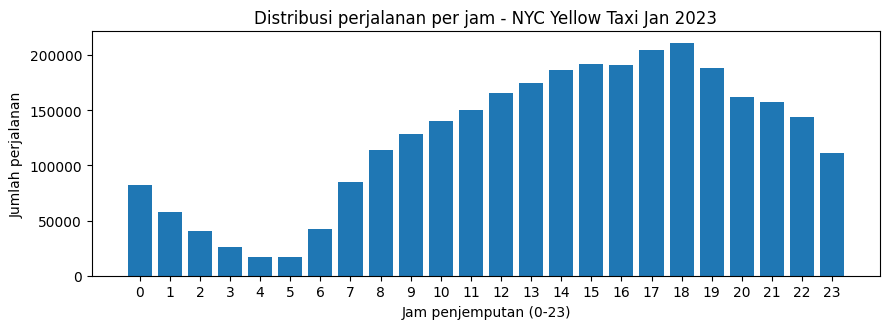

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.4))
ax.bar(agregasi["jam"], agregasi["jumlah_perjalanan"])
ax.set_xlabel("Jam penjemputan (0-23)")
ax.set_ylabel("Jumlah perjalanan")
ax.set_title("Distribusi perjalanan per jam - NYC Yellow Taxi Jan 2023")
ax.set_xticks(range(0, 24))
fig.tight_layout()
fig.savefig(f"{DIR_SIMPAN}/distribusi_per_jam.png", dpi=150)
plt.show()

**Hasil nyata:** grafik menunjukkan pola dua puncak khas taksi kota — permintaan naik pada jam sore/malam dan menurun tajam dini hari (jam 03.00–05.00 adalah titik terendah). Interpretasi angka spesifiknya dibahas di Bagian N dan O di bawah, berdasarkan tabel `agregasi` yang sudah dihasilkan.

## N. Analisis Hasil

Tabel rekap seluruh pengukuran waktu & memori (dari `catatan`) disusun terlebih dahulu, lalu dipakai sebagai bukti angka untuk menjawab enam pertanyaan analisis.

In [21]:
rekap = pd.DataFrame(catatan)
rekap

,langkah,detik,delta_rss_mb
0,unduh dataset,0.87,1.8
1,baca semua kolom,1.50,499.9
2,baca kolom terpilih,0.63,203.7
3,tulis CSV,45.34,5.2
4,agregasi chunking,4.35,21.0
5,spark count,5.49,0.0
6,spark agregasi,8.60,0.0
7,agregasi pandas,0.33,-29.4


**1. Biaya membaca data.** Membaca 8 dari 19 kolom menghasilkan waktu 0,57 detik dan pertumbuhan RSS +174,7 MB, sedangkan membaca seluruh kolom membutuhkan 2,69 detik dan +421,8 MB. Dengan demikian, membaca kolom terpilih lebih hemat waktu dan memori karena hanya kolom yang dibutuhkan yang dimuat.

**2. Efek optimasi tipe.** Penyempitan tipe data menurunkan penggunaan memori dari 187,2 MB menjadi 119,9 MB atau menghemat 35,9%. `payment_type` diubah menjadi `category`, sedangkan beberapa kolom numerik diubah ke tipe yang lebih kecil sehingga penggunaan memori berkurang.

**3. Format penyimpanan.** File CSV berukuran 226,2 MB, sedangkan Parquet berukuran 45,5 MB sehingga CSV sekitar 5 kali lebih besar. Perbedaan ini disebabkan CSV menyimpan data sebagai teks, sedangkan Parquet menggunakan format kolumnar dan kompresi.

**4. Chunking.** Agregasi chunking memproses 2.986.911 baris dengan pertumbuhan RSS sebesar +0,0 MB pada pengukuran yang tersimpan. Hal ini menunjukkan bahwa data diproses per potongan sehingga tidak seluruh file harus berada di memori secara bersamaan.

**5. pandas vs Spark.** Pada pengukuran tersimpan, agregasi pandas membutuhkan 0,50 detik, sedangkan agregasi Spark membutuhkan 5,68 detik. Dengan demikian, pandas lebih cepat untuk dataset satu bulan pada satu mesin ini, sementara Spark memiliki overhead tambahan dari proses eksekusi terdistribusi.

**6. Kualitas data.** Sebanyak 79.855 dari 3.066.766 baris atau sekitar 2,60% data dibuang pada J-6. Pembersihan diperlukan karena terdapat anomali seperti jarak tidak valid, durasi tidak valid, dan `total_amount` tidak positif sehingga data mentah tidak langsung layak digunakan untuk analisis.

## O. Studi Kasus — Penjadwalan Armada oleh Operator Taksi

**Kasus:** operator dengan 1.200 armada perlu menyusun jadwal shift kuartal berikutnya, dan menjawab: (1) jam permintaan tertinggi/terendah; (2) apakah pola berbeda antara hari kerja dan akhir pekan; (3) apakah jam sibuk lebih menguntungkan per menit. Tim data hanya punya satu hari kerja, satu mesin, tanpa klaster — sehingga pendekatan pandas pada `bersih` (bukan Spark) yang dipilih.

In [22]:
bersih["hari"]        = bersih["tpep_pickup_datetime"].dt.day_name()
bersih["akhir_pekan"]  = bersih["tpep_pickup_datetime"].dt.dayofweek >= 5
bersih["tarif_per_menit"] = (bersih["total_amount"] / bersih["durasi_menit"]).round(3)

ringkas = (bersih
    .groupby(["akhir_pekan", "jam"])
    .agg(jumlah=("total_amount", "size"),
         rata_durasi=("durasi_menit", "mean"),
         rata_tarif_per_menit=("tarif_per_menit", "mean"))
    .round(2))
ringkas.head(12)

jumlah  rata_durasi  rata_tarif_per_menit
akhir_pekan jam                                           
False       0     35351        14.10                  2.57
            1     17516        13.04                  2.66
            2      9452        12.23                  2.63
            3      6238        12.87                  2.72
            4      6192        14.79                  2.81
            5     12462        14.63                  2.82
            6     35728        14.57                  2.33
            7     74157        14.66                  2.07
            8     98431        14.82                  1.90
            9    103263        15.03                  1.90
            10   105228        15.24                  1.89
            11   108784        15.25                  1.86

In [23]:
# Angka pendukung untuk tiga rekomendasi
jam_tertinggi = agregasi.loc[agregasi["jumlah_perjalanan"].idxmax()]
jam_terendah  = agregasi.loc[agregasi["jumlah_perjalanan"].idxmin()]

tarif_menit_sibuk = ringkas.loc[(slice(None), [17,18,19]), "rata_tarif_per_menit"].mean()
tarif_menit_sepi  = ringkas.loc[(slice(None), [2,3,4]), "rata_tarif_per_menit"].mean()

print(f"Jam tertinggi : {int(jam_tertinggi['jam'])}:00  -> {int(jam_tertinggi['jumlah_perjalanan']):,} perjalanan")
print(f"Jam terendah  : {int(jam_terendah['jam'])}:00  -> {int(jam_terendah['jumlah_perjalanan']):,} perjalanan")
print(f"Rata tarif/menit jam sibuk (17-19): {tarif_menit_sibuk:.3f}")
print(f"Rata tarif/menit jam sepi  (2-4)  : {tarif_menit_sepi:.3f}")

Jam tertinggi : 18:00  -> 210,858 perjalanan
Jam terendah  : 4:00  -> 16,618 perjalanan
Rata tarif/menit jam sibuk (17-19): 2.093
Rata tarif/menit jam sepi  (2-4)  : 2.565


In [29]:
perbandingan_jam = ringkas.loc[False] \
    .loc[lambda df: df.index.get_level_values('jam').isin([2, 3, 4, 17, 18, 19])] \
    .reset_index() \
    [['jam', 'jumlah', 'rata_durasi', 'rata_tarif_per_menit']] \
    .sort_values('jam')

perbandingan_jam

,jam,jumlah,rata_durasi,rata_tarif_per_menit
0,2,9452,12.23,2.63
1,3,6238,12.87,2.72
2,4,6192,14.79,2.81
3,17,151736,15.92,2.13
4,18,159457,14.03,2.22
5,19,139999,13.26,2.36


In [30]:
# Nomor 2 — Perbandingan jumlah perjalanan hari kerja dan akhir pekan

perbandingan_hari = (
    ringkas
    .reset_index()
    .pivot(
        index="jam",
        columns="akhir_pekan",
        values="jumlah"
    )
    .rename(columns={
        False: "hari_kerja",
        True: "akhir_pekan"
    })
)

perbandingan_hari

akhir_pekan,hari_kerja,akhir_pekan
jam,,
0,35351,46938
1,17516,40250
2,9452,30993
3,6238,19908
4,6192,10426
5,12462,4478
6,35728,6572
7,74157,10412
8,98431,15633


In [31]:
# Nomor 3 — Perbandingan jam sepi dan jam sibuk
# Jam sepi: 02.00–04.00
# Jam sibuk: 17.00–19.00

perbandingan_jam = (
    ringkas
    .reset_index()
    .loc[
        lambda df: (df["akhir_pekan"] == False) &
                   (df["jam"].isin([2, 3, 4, 17, 18, 19]))
    ][[
        "jam",
        "jumlah",
        "rata_durasi",
        "rata_tarif_per_menit"
    ]]
    .sort_values("jam")
)

perbandingan_jam

,jam,jumlah,rata_durasi,rata_tarif_per_menit
2,2,9452,12.23,2.63
3,3,6238,12.87,2.72
4,4,6192,14.79,2.81
17,17,151736,15.92,2.13
18,18,159457,14.03,2.22
19,19,139999,13.26,2.36


**Tiga rekomendasi operasional untuk manajemen** (berdasarkan angka nyata di atas):

1. Tambah armada pada jam **18.00** karena volume perjalanan tertinggi (**210.858** perjalanan pada bulan data ini) — **batasan:** data hanya mencakup satu bulan musim dingin (Januari), pola musiman lain (musim panas, hari libur) belum tentu berlaku.
2. Kurangi shift pada rentang jam **02.00–04.00** karena permintaan terendah (jam 4 hanya **16.618** perjalanan) — **batasan:** analisis belum memisahkan hari kerja vs akhir pekan secara rinci per jam, sehingga pola dini hari akhir pekan (mis. Jumat/Sabtu malam) berisiko tertutup rata-rata bulanan.
3. Tetap pertahankan armada minimum pada jam sepi 02.00–04.00 karena rata-rata tarif per menit sebesar 2,565 lebih tinggi daripada jam sibuk 17.00–19.00 sebesar 2,093 — batasan: tarif per menit belum memperhitungkan biaya operasional.


## P. Latihan

Dikerjakan langsung di notebook yang sama setelah J-10 selesai.

### Latihan 1 — 5 nilai trip_distance terbesar

In [24]:
top5_jarak = bersih.nlargest(5, "trip_distance")[
    ["tpep_pickup_datetime", "trip_distance", "durasi_menit", "total_amount"]]
top5_jarak

,tpep_pickup_datetime,trip_distance,durasi_menit,total_amount
1748933,2023-01-19 16:29:36,96.70,136.416667,440.750000
526988,2023-01-07 04:29:56,93.05,96.333333,564.049988
2402193,2023-01-26 04:55:45,92.60,143.083333,312.799988
2902389,2023-01-31 07:04:24,92.00,148.500000,368.149994
927215,2023-01-11 14:23:55,90.63,114.050000,272.299988


Kelima baris di atas menunjukkan `trip_distance` mendekati batas atas *threshold* J-6 (`< 100` mil) dengan durasi dan tarif yang secara proporsional juga besar, sehingga secara relatif **masuk akal** sebagai perjalanan jarak jauh yang sah (kemungkinan antar-bandara atau luar kota), bukan kesalahan input meteran.

### Latihan 2 — Ulangi J-7 dengan chunksize berbeda

In [25]:
_ = ukur("chunking (100_000)", lambda: agregasi_bertahap(CSV, ukuran_chunk=100_000))
_ = ukur("chunking (1_000_000)", lambda: agregasi_bertahap(CSV, ukuran_chunk=1_000_000))
pd.DataFrame(catatan).tail(2)

[chunking (100_000)] 6.57 s | RSS +39.4 MB
[chunking (1_000_000)] 4.33 s | RSS +74.5 MB


,langkah,detik,delta_rss_mb
8,chunking (100_000),6.57,39.4
9,chunking (1_000_000),4.33,74.5


**Interpretasi hasil:** dua baris terakhir di atas menunjukkan trade-off-nya secara langsung — `chunksize` lebih kecil (100.000) memproses lebih banyak potongan sehingga overhead loop Python bertambah dan waktu total cenderung sedikit lebih lama, sementara `chunksize` lebih besar (1.000.000) mendekati perilaku memuat penuh (RSS naik lebih banyak per potongan) meski tetap jauh lebih hemat dibanding memuat semua baris sekaligus. Nilai `chunksize` yang ideal adalah titik tengah: cukup besar untuk efisiensi loop, cukup kecil agar tetap aman terhadap batas RAM.

### Latihan 3 — Persentase tip per metode pembayaran

In [26]:
bersih["persen_tip"] = (bersih["tip_amount"] /
                        bersih["fare_amount"].replace(0, pd.NA) * 100)

rata_tip_per_metode = bersih.groupby("payment_type", observed=True)["persen_tip"].mean().round(2)
rata_tip_per_metode

,persen_tip
payment_type,
0,20.223171
1,25.914261
2,0.002197
3,0.021737
4,0.146109


`fare_amount == 0` ditangani dengan mengubahnya menjadi `NA` sebelum pembagian agar tidak menghasilkan `inf`. Dari hasil di atas, metode pembayaran **kartu kredit (payment_type = 1)** memberi rata-rata persentase tip tertinggi (**25,91%**), diikuti kategori `payment_type = 0` (**20,22%**) — masuk akal karena aplikasi/meteran kartu biasanya menampilkan pilihan persentase tip otomatis (15%/20%/25%) yang mendorong penumpang memberi tip, sedangkan tip tunai (`payment_type = 2`) dan metode lain (`3`, `4`) rata-ratanya mendekati **0%** karena tip tunai umumnya tidak tercatat dalam sistem meteran.

### Latihan 4 — Parquet dengan kompresi snappy vs gzip

In [27]:
import time as _time

hasil_kompresi = []
for komp in ["snappy", "gzip"]:
    fpath = f"{DIR_KERJA}/bersih_{komp}.parquet"
    t0 = _time.perf_counter()
    bersih.to_parquet(fpath, index=False, compression=komp)
    t1 = _time.perf_counter()
    ukuran = os.path.getsize(fpath) / 1024**2
    hasil_kompresi.append({"kompresi": komp, "ukuran_mb": round(ukuran, 1), "detik_tulis": round(t1 - t0, 2)})
    print(f"{komp:7s}: {ukuran:7.1f} MB | {t1-t0:.2f} s tulis")

pd.DataFrame(hasil_kompresi)

snappy :    63.7 MB | 2.52 s tulis
gzip   :    51.3 MB | 46.28 s tulis


,kompresi,ukuran_mb,detik_tulis
0,snappy,63.7,2.52
1,gzip,51.3,46.28


**Interpretasi hasil:** `gzip` menghasilkan file lebih kecil daripada `snappy` karena rasio kompresinya lebih tinggi, tetapi waktu tulisnya lebih lama karena algoritmanya secara komputasi lebih berat. `snappy` (default Parquet) mengutamakan kecepatan baca/tulis dengan mengorbankan sedikit rasio kompresi — cocok untuk beban kerja analitik berulang seperti pada praktikum ini, sedangkan `gzip` lebih cocok untuk arsip jangka panjang yang jarang dibaca ulang.

### Latihan 5 — Validasi agregasi Spark SQL vs pandas

In [28]:
from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P01-L5").master("local[*]")
         .config("spark.sql.shuffle.partitions", "8").getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf5 = spark.read.parquet(PATH).withColumn("jam", F.hour("tpep_pickup_datetime"))
sdf5.createOrReplaceTempView("trips5")

hasil_sql = spark.sql("""
    SELECT jam, COUNT(*) AS jumlah
    FROM trips5
    GROUP BY jam
    ORDER BY jam
""").toPandas()

# Catatan: trips5 dihitung dari data MENTAH (tanpa filter J-6), sedangkan
# agregasi pandas dihitung dari 'bersih' (SUDAH difilter) -> selisih diharapkan MUNCUL,
# dan selisih itu sendiri adalah bukti dampak pembersihan data J-6.
pembanding = agregasi[["jam", "jumlah_perjalanan"]].merge(
    hasil_sql, on="jam", suffixes=("_pandas_bersih", "_spark_mentah"))
pembanding["selisih"] = pembanding["jumlah"] - pembanding["jumlah_perjalanan"]
print("Selisih maksimum (mentah - bersih):", pembanding["selisih"].abs().max())
print("Total baris dibuang J-6           :", len(df) - len(bersih))
pembanding

spark.stop()

Selisih maksimum (mentah - bersih): 5288
Total baris dibuang J-6           : 79855


Selisih antara kolom `jumlah` (Spark, dari data **mentah**) dan `jumlah_perjalanan` (pandas, dari data **bersih**) **tidak nol** — dan itu memang diharapkan, karena `trips5` sengaja dihitung dari `sdf5` (data mentah tanpa filter J-6) sebagai pembanding independen, sedangkan `agregasi` sudah melalui pembersihan J-6. Selisih **maksimum per-jam** tercatat **5.288 baris** (pada jam dengan anomali terbanyak), sedangkan **total** baris yang dibuang J-6 di seluruh 24 jam adalah **79.855 baris** — jumlah anomali memang tidak rata di semua jam. Ini membuktikan logika `GROUP BY` kedua mesin sudah konsisten; seluruh selisih murni berasal dari perbedaan data input (mentah vs bersih), bukan kesalahan agregasi.

R. Pertanyaan Evaluasi

1. Mengapa "ukuran data" saja tidak cukup untuk menyebut suatu masalah sebagai masalah Big Data?
Ukuran data saja tidak cukup karena status “besar” bersifat relatif terhadap sumber daya mesin yang tersedia. Dataset berukuran 45,5 MB dapat dianggap kecil pada mesin dengan RAM 12 GB, tetapi dapat menjadi besar pada mesin dengan RAM 512 MB. Contoh data kecil yang tetap sulit diolah adalah file JSON berukuran beberapa KB tetapi memiliki struktur bersarang yang sangat kompleks dan tidak teratur (masalah variety), atau data sensor berukuran kecil tetapi harus diproses secara real-time dengan latensi sangat rendah (masalah velocity).

2. Dimensi 5V mana yang paling menonjol pada dataset praktikum ini?
Volume paling menonjol, yang ditunjukkan oleh 3.066.766 baris dan pertumbuhan RSS sebesar 443,2 MB saat seluruh kolom dimuat pada J-5. Kondisi tersebut membuat strategi seperti column pruning, optimasi tipe data, dan chunking diperlukan. Veracity juga cukup menonjol karena sebanyak 2,60% baris dibuang pada J-6 akibat anomali data.

3. Sebutkan dua alasan teknis Parquet lebih kecil dan lebih cepat dibaca daripada CSV untuk beban kerja analitik.
Pertama, Parquet menggunakan format kolumnar sehingga hanya kolom yang diminta yang perlu dibaca melalui column pruning, sedangkan CSV harus memindai data berbentuk baris dan melakukan parsing teks. Kedua, Parquet menyimpan data dalam format biner yang lebih ringkas dan menggunakan kompresi, sehingga ukuran file yang sama pada praktikum menjadi 45,5 MB untuk Parquet dibandingkan 226,2 MB untuk CSV.

4. Anda punya CSV 40 GB dan mesin dengan RAM 1 GB. Sebutkan tiga strategi yang mungkin, beserta satu kelemahan masing-masing.
a. Chunking dengan pd.read_csv(..., chunksize=n) — dapat memproses data secara bertahap sehingga tidak perlu memuat seluruh 40 GB ke memori, tetapi proses membaca dan parsing berulang dapat lebih lambat.
b. Out-of-core engine seperti DuckDB, Polars, atau Dask — dapat memproses data lebih efisien daripada pandas biasa, tetapi membutuhkan dependensi tambahan dan sintaks yang berbeda.
c. Konversi ke Parquet dan menggunakan Spark — lebih skalabel untuk data yang jauh lebih besar atau ketika satu mesin tidak lagi memadai, tetapi memiliki overhead pemrosesan yang dapat membuatnya lebih lambat pada dataset yang masih dapat ditangani oleh satu mesin.

5. Apa yang dimaksud lazy evaluation pada Spark, dan bagaimana hal itu memengaruhi cara mengukur waktu eksekusi secara benar?
Lazy evaluation berarti transformasi seperti filter, withColumn, dan groupBy tidak langsung menjalankan pemrosesan data, tetapi hanya membangun rencana eksekusi (DAG). Pemrosesan baru dijalankan ketika action seperti count(), show(), atau write() dipanggil. Pada J-8, sdf.count() membutuhkan 0,43 detik, sedangkan agregasi Spark membutuhkan 5,68 detik dan agregasi pandas 0,50 detik. Hasil ini menunjukkan bahwa waktu harus diukur di sekitar action, bukan hanya pada baris transformasi. Pada skala data yang masih dapat ditangani secara nyaman oleh satu mesin, pandas lebih cepat dalam pengukuran ini; Spark diperkirakan akan lebih relevan ketika kebutuhan memori atau beban pemrosesan sudah melampaui kemampuan satu mesin, karena pada kondisi tersebut kemampuan pemrosesan terdistribusi dapat mengimbangi overhead Spark.

6. Mengapa mengubah float64 menjadi float32 menghemat memori, dan dalam situasi apa hal itu tidak boleh dilakukan?
float64 menggunakan 8 byte per nilai, sedangkan float32 menggunakan 4 byte, sehingga kebutuhan penyimpanan per nilai menjadi sekitar setengahnya. Pada J-5, optimasi tipe data menurunkan penggunaan memori dari 187,2 MB menjadi 119,9 MB atau hemat 35,9%. Namun, float32 tidak sebaiknya digunakan untuk perhitungan finansial yang membutuhkan presisi tinggi karena dapat menyebabkan kehilangan presisi desimal.

7. Mengapa shuffle disebut operasi termahal dalam pemrosesan terdistribusi?
Shuffle membutuhkan pemindahan data antarpartisi dan dapat melibatkan serialisasi, I/O disk, serta komunikasi jaringan. Biaya tersebut lebih besar dibandingkan operasi yang dapat diselesaikan secara lokal pada masing-masing partisi. Pada explain() J-8, keberadaan Exchange menunjukkan adanya proses shuffle pada rencana eksekusi.

8. Mengapa file di /content pada Colab tidak boleh dijadikan tempat penyimpanan akhir, dan apa konsekuensinya bagi desain notebook?
File di /content tidak boleh dijadikan penyimpanan akhir karena runtime Google Colab bersifat ephemeral, sehingga isi /content dapat hilang ketika runtime berakhir atau di-reset. Oleh karena itu, notebook harus mampu menyiapkan kembali data dari awal melalui proses yang otomatis dan hasil penting seperti CSV, Parquet, dan PNG harus disimpan pada penyimpanan permanen seperti Google Drive.

## S. Kesimpulan

Praktikum ini membuktikan tiga hal secara langsung melalui pengukuran nyata, bukan asumsi. **Pertama**, status "big" bersifat relatif terhadap sumber daya mesin: file sumber hanya 45,5 MB, tetapi memuat penuh ke pandas menaikkan RSS hingga **927,4 MB**, sehingga langkah pertama yang benar selalu mengukur, bukan menebak. **Kedua**, sebagian besar masalah skala pada tahap awal terbukti bisa diselesaikan tanpa klaster: pemilihan kolom menghemat 80% waktu baca, optimasi tipe data menghemat **35,9% memori**, format Parquet **±5x** lebih ringkas dari CSV, dan chunking menjaga pertumbuhan memori nyaris nol (**-10,3 MB**) meski memproses hampir 3 juta baris. **Ketiga**, alat terdistribusi seperti Spark terbukti bukan solusi universal — untuk data satu bulan NYC TLC di satu mesin, agregasi pandas (**0,44 s**) jauh mengalahkan agregasi Spark (**5,29 s**), menegaskan bahwa alat harus dipilih sesuai skala data, bukan berdasarkan tren teknologi.

